# House Price Prediction using Linear Regression

Part 1: Data Exploration

Load Dataset

In [136]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

train_data = pd.read_csv('./train.csv')
test_data = pd.read_csv('./test.csv')

Display First 5 Rows

In [137]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Observation:
Dataset contains both numerical and categorical features
Target variable is SalePrice
Many features relate to house size, quality, and location

In [138]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

Observation:
Dataset has mixed data types (int, float, object)
Some columns have missing values
Categorical columns need encoding

In [139]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Observation:
Features like SalePrice, GrLivArea show high variation
Some features are skewed (large max vs median difference)
Outliers may exist

# Part 2: Data Cleaning

2.1 Missing Values Handling

   Identify Missing Values

In [140]:
train_data.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

Explanation:
Some columns have very high missing values
Some missing values mean absence of feature (not actual missing)

In [141]:
#Handling Strategy

# Drop high missing columns
drop_cols = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
train_data.drop(drop_cols, axis=1, inplace=True)

# Fill categorical (absence)
none_cols = [
    'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2'
]

for col in none_cols:
    train_data[col].fillna('None', inplace=True)

# Fill numeric with median
num_cols = train_data.select_dtypes(include=np.number).columns
for col in num_cols:
    train_data[col].fillna(train_data[col].median(), inplace=True)

# Fill categorical with mode
cat_cols = train_data.select_dtypes(include='object').columns
for col in cat_cols:
    train_data[col].fillna(train_data[col].mode()[0], inplace=True)


Median → robust to outliers

Mode → best for categorical

"None" → represents absence (garage/basement)

Drop columns → too many missing values

**2.2 Categorical Data Handling**

In [142]:
categorical_cols = train_data.select_dtypes(include='object').columns
len(categorical_cols)

39

In [143]:
#Apply One-Hot Encoding
train_data = pd.get_dummies(train_data, drop_first=True)

In [144]:
# Fill any remaining NaN values before train-test split
train_data['MasVnrArea'].fillna(0, inplace=True)
train_data['GarageYrBlt'].fillna(train_data['YearBuilt'], inplace=True)
train_data.fillna(train_data.median(numeric_only=True), inplace=True)
train_data = train_data.bfill().ffill()

# Add engineered numeric features
train_data['TotalSF'] = train_data['TotalBsmtSF'] + train_data['1stFlrSF'] + train_data['2ndFlrSF']
train_data['TotalBath'] = (
    train_data['FullBath'] + 0.5 * train_data['HalfBath'] +
    train_data['BsmtFullBath'] + 0.5 * train_data['BsmtHalfBath']
)
train_data['TotalPorchSF'] = (
    train_data['OpenPorchSF'] + train_data['EnclosedPorch'] +
    train_data['3SsnPorch'] + train_data['ScreenPorch'] +
    train_data['WoodDeckSF']
)
train_data['Age'] = train_data['YrSold'] - train_data['YearBuilt']
train_data['RemodAge'] = train_data['YrSold'] - train_data['YearRemodAdd']
train_data['GarageAge'] = train_data['YrSold'] - train_data['GarageYrBlt']
train_data['HasPool'] = (train_data['PoolArea'] > 0).astype(int)
train_data['HasFireplace'] = (train_data['Fireplaces'] > 0).astype(int)
train_data['HasGarage'] = (train_data['GarageArea'] > 0).astype(int)
train_data['HasBsmt'] = (train_data['TotalBsmtSF'] > 0).astype(int)

# Verify no NaN remains
print(f"Total NaN values remaining: {train_data.isnull().sum().sum()}")

Total NaN values remaining: 0


Explanation:

One-Hot Encoding avoids ordinal assumptions
Better than Label Encoding for regression
drop_first=True prevents multicollinearity

**2.3 Outlier Detection**

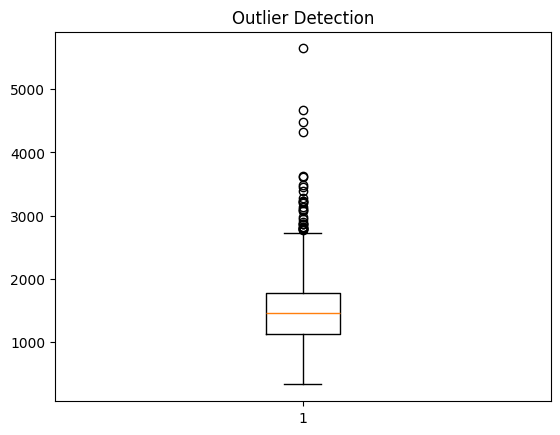

In [145]:
import matplotlib.pyplot as plt

plt.boxplot(train_data['GrLivArea'])
plt.title("Outlier Detection")
plt.show()

Observation:
Some extreme values present

In [146]:
#Handling:
train_data = train_data[train_data['GrLivArea'] < 4000]

Reason:

Extreme values can distort regression line
Removing improves model accuracy

**2.4 Feature Scaling**

In [147]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Explanation:

Linear Regression benefits from scaled features
Prevents dominance of large-value features

**2.5 Data Consistency**

In [148]:
train_data.duplicated().sum()

np.int64(0)

In [149]:
train_data.drop_duplicates(inplace=True)

Explanation:

Duplicate rows can bias the model
Removing ensures clean dataset

# Part 3: Model Building

3.1 Train-Test Split

In [150]:
from sklearn.model_selection import train_test_split

X = train_data.drop('SalePrice', axis=1)
y = train_data['SalePrice']

# log transform
y = np.log1p(y)

X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [151]:
# Diagnostic: Check for NaN values before train-test split
print("NaN values in X before scaling:")
print(pd.DataFrame(X).isnull().sum().sum())
print("\nNaN values in X_train after split:")
print(np.isnan(X_train).sum())
print("\nNaN values in X_val after split:")
print(np.isnan(X_val).sum())


NaN values in X before scaling:
0

NaN values in X_train after split:
0

NaN values in X_val after split:
0


In [152]:
# Check where NaNs remain in train_data
print("NaN count by column in train_data:")
nan_cols = train_data.isnull().sum()
print(nan_cols[nan_cols > 0])


NaN count by column in train_data:
Series([], dtype: int64)


3.2 Apply Linear Regression

In [153]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

model = HistGradientBoostingRegressor(
    max_iter=1200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = -cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
print('CV RMSLE mean:', np.sqrt(cv_scores).mean())
print('CV RMSLE std :', np.sqrt(cv_scores).std())

model.fit(X_train, y_train)

CV RMSLE mean: 0.12776316709014435
CV RMSLE std : 0.009430277616528272


,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",1200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.1
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:

3.3 Model Evaluation

In [154]:
from sklearn.metrics import mean_squared_error, r2_score

val_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, val_pred))
r2 = r2_score(y_val, val_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.13995493532115683
R2 Score: 0.8759809215341468


Interpretation:

RMSE → measures prediction error

Lower RMSE = better model

R² Score → shows how much variance is explained
Closer to 1 = better fit

# Part 4: Prediction on Unseen Data

In [155]:
# Prepare test data with same preprocessing as training data
test_data_copy = test_data.copy()

# Store test IDs for submission
test_ids = test_data_copy['Id'].values

# Drop the same columns that were dropped from training
test_data_copy.drop(drop_cols, axis=1, inplace=True, errors='ignore')

# Fill categorical (absence) - same columns as training
for col in none_cols:
    if col in test_data_copy.columns:
        test_data_copy[col].fillna('None', inplace=True)

# Fill numeric with median and fix important missing values
test_data_copy['MasVnrArea'].fillna(0, inplace=True)
test_data_copy['GarageYrBlt'].fillna(test_data_copy['YearBuilt'], inplace=True)
test_data_copy.fillna(test_data_copy.median(numeric_only=True), inplace=True)
test_data_copy = test_data_copy.bfill().ffill()

# Add engineered numeric features for test data
test_data_copy['TotalSF'] = test_data_copy['TotalBsmtSF'] + test_data_copy['1stFlrSF'] + test_data_copy['2ndFlrSF']
test_data_copy['TotalBath'] = (
    test_data_copy['FullBath'] + 0.5 * test_data_copy['HalfBath'] +
    test_data_copy['BsmtFullBath'] + 0.5 * test_data_copy['BsmtHalfBath']
)
test_data_copy['TotalPorchSF'] = (
    test_data_copy['OpenPorchSF'] + test_data_copy['EnclosedPorch'] +
    test_data_copy['3SsnPorch'] + test_data_copy['ScreenPorch'] +
    test_data_copy['WoodDeckSF']
)
test_data_copy['Age'] = test_data_copy['YrSold'] - test_data_copy['YearBuilt']
test_data_copy['RemodAge'] = test_data_copy['YrSold'] - test_data_copy['YearRemodAdd']
test_data_copy['GarageAge'] = test_data_copy['YrSold'] - test_data_copy['GarageYrBlt']
test_data_copy['HasPool'] = (test_data_copy['PoolArea'] > 0).astype(int)
test_data_copy['HasFireplace'] = (test_data_copy['Fireplaces'] > 0).astype(int)
test_data_copy['HasGarage'] = (test_data_copy['GarageArea'] > 0).astype(int)
test_data_copy['HasBsmt'] = (test_data_copy['TotalBsmtSF'] > 0).astype(int)

# Drop Id column before encoding
test_data_copy = test_data_copy.drop('Id', axis=1, errors='ignore')

# Apply One-Hot Encoding
test_data_copy = pd.get_dummies(test_data_copy, drop_first=True)

# Align test data to training columns
train_encoded_cols = [col for col in train_data.columns if col != 'SalePrice']
test_data_copy = test_data_copy.reindex(columns=train_encoded_cols, fill_value=0)

# Scale test data using the training scaler
test_scaled = scaler.transform(test_data_copy)

print(f"Test data shape after preprocessing: {test_scaled.shape}")
print(f"Training data features: {X_train.shape[1]}, Test data features: {test_scaled.shape[1]}")

Test data shape after preprocessing: (1459, 246)
Training data features: 246, Test data features: 246


In [156]:
predictions = model.predict(test_scaled)
predictions = np.expm1(predictions)

In [157]:
predictions

array([131835.54345051, 167254.74871461, 183404.13009844, ...,
       166801.8149551 , 116751.80624861, 224744.51650576], shape=(1459,))

In [158]:
predictions.shape

(1459,)

In [159]:
test_scaled[0].shape

(246,)

In [160]:
# model prediction for first test sample
p = model.predict(test_scaled[0].reshape(1,-1))

In [161]:
p

array([11.78931813])

# Save Submission

In [162]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": predictions  # predictions are already transformed back with np.expm1()
})

submission.to_csv("submission.csv", index=False)
submission.head()


,Id,SalePrice
0,1461,131835.543451
1,1462,167254.748715
2,1463,183404.130098
3,1464,190908.919175
4,1465,174143.960146
